<a href="https://www.kaggle.com/code/lalit7881/u-s-chronic-disease-indicators-cdc-eda?scriptVersionId=314944783" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lalit7881/u-s-chronic-disease-indicators-cdc/U.S._Chronic_Disease_Indicators.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lalit7881/u-s-chronic-disease-indicators-cdc/U.S._Chronic_Disease_Indicators.csv")

In [3]:
df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
309210,2022,2022,VI,Virgin Islands,BRFSS,Tobacco,Quit attempts in the past year among adult cur...,NaN,%,Age-adjusted Prevalence,...,TOB,TOB06,NaN,AGEADJPREV,RACE,AIAN,NaN,NaN,NaN,NaN
309211,2022,2022,WV,West Virginia,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,NaN,%,Crude Prevalence,...,COPD,COPD01,NaN,CRDPREV,OVERALL,OVR,NaN,NaN,NaN,NaN
309212,2022,2022,WI,Wisconsin,BRFSS,Immunization,Pneumococcal vaccination among adults aged 65 ...,NaN,%,Crude Prevalence,...,IMM,IMM04,NaN,CRDPREV,RACE,BLK,NaN,NaN,NaN,NaN
309213,2022,2022,VT,Vermont,BRFSS,Social Determinants of Health,Lack of health insurance among adults aged 18-...,NaN,%,Crude Prevalence,...,SDOH,SDH09,NaN,CRDPREV,RACE,HAPI,NaN,NaN,NaN,NaN
309214,2022,2022,WA,Washington,BRFSS,Alcohol,Binge drinking prevalence among adults,NaN,%,Age-adjusted Prevalence,...,ALC,ALC06,NaN,AGEADJPREV,SEX,SEXM,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309215 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  309215 non-null  int64  
 1   YearEnd                    309215 non-null  int64  
 2   LocationAbbr               309215 non-null  object 
 3   LocationDesc               309215 non-null  object 
 4   DataSource                 309215 non-null  object 
 5   Topic                      309215 non-null  object 
 6   Question                   309215 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              309215 non-null  object 
 9   DataValueType              309215 non-null  object 
 10  DataValue                  209196 non-null  float64
 11  DataValueAlt               209196 non-null  float64
 12  DataValueFootnoteSymbol    101716 non-null  object 
 13  DataValueFootnote          10

In [6]:
df.describe()

,YearStart,YearEnd,Response,DataValue,DataValueAlt,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,LocationID,ResponseID,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
count,309215.000000,309215.000000,0.0,2.091960e+05,2.091960e+05,188885.000000,188890.000000,0.0,0.0,0.0,0.0,309215.000000,0.0,0.0,0.0,0.0,0.0
mean,2020.012195,2020.288540,NaN,6.943569e+02,7.356701e+02,36.825051,46.030554,NaN,NaN,NaN,NaN,31.208693,NaN,NaN,NaN,NaN,NaN
std,1.530835,1.068591,NaN,1.620341e+04,1.834715e+04,65.025590,69.995643,NaN,NaN,NaN,NaN,17.798773,NaN,NaN,NaN,NaN,NaN
min,2015.000000,2019.000000,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2019.000000,2019.000000,NaN,1.240000e+01,1.240000e+01,9.100000,14.000000,NaN,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,NaN,NaN
50%,2020.000000,2020.000000,NaN,2.700000e+01,2.700000e+01,19.500000,29.200000,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN
75%,2021.000000,2021.000000,NaN,5.780000e+01,5.780000e+01,40.300000,54.300000,NaN,NaN,NaN,NaN,45.000000,NaN,NaN,NaN,NaN,NaN
max,2022.000000,2022.000000,NaN,2.925456e+06,2.925456e+06,1427.000000,1485.900000,NaN,NaN,NaN,NaN,78.000000,NaN,NaN,NaN,NaN,NaN


In [7]:
df.isnull().sum()

YearStart                         0
YearEnd                           0
LocationAbbr                      0
LocationDesc                      0
DataSource                        0
Topic                             0
Question                          0
Response                     309215
DataValueUnit                     0
DataValueType                     0
DataValue                    100019
DataValueAlt                 100019
DataValueFootnoteSymbol      207499
DataValueFootnote            207499
LowConfidenceLimit           120330
HighConfidenceLimit          120325
StratificationCategory1           0
Stratification1                   0
StratificationCategory2      309215
Stratification2              309215
StratificationCategory3      309215
Stratification3              309215
Geolocation                    5763
LocationID                        0
TopicID                           0
QuestionID                        0
ResponseID                   309215
DataValueTypeID             

In [8]:
df.dtypes

YearStart                      int64
YearEnd                        int64
LocationAbbr                  object
LocationDesc                  object
DataSource                    object
Topic                         object
Question                      object
Response                     float64
DataValueUnit                 object
DataValueType                 object
DataValue                    float64
DataValueAlt                 float64
DataValueFootnoteSymbol       object
DataValueFootnote             object
LowConfidenceLimit           float64
HighConfidenceLimit          float64
StratificationCategory1       object
Stratification1               object
StratificationCategory2      float64
Stratification2              float64
StratificationCategory3      float64
Stratification3              float64
Geolocation                   object
LocationID                     int64
TopicID                       object
QuestionID                    object
ResponseID                   float64
D

In [9]:
df.shape

(309215, 34)

In [10]:
df.nunique()

YearStart                        7
YearEnd                          4
LocationAbbr                    55
LocationDesc                    55
DataSource                      14
Topic                           19
Question                       109
Response                         0
DataValueUnit                    8
DataValueType                   12
DataValue                    14852
DataValueAlt                 14852
DataValueFootnoteSymbol          9
DataValueFootnote                9
LowConfidenceLimit            8412
HighConfidenceLimit           8861
StratificationCategory1          5
Stratification1                 26
StratificationCategory2          0
Stratification2                  0
StratificationCategory3          0
Stratification3                  0
Geolocation                     54
LocationID                      55
TopicID                         19
QuestionID                     109
ResponseID                       0
DataValueTypeID                 12
StratificationCatego

In [11]:
df.columns

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource',
       'Topic', 'Question', 'Response', 'DataValueUnit', 'DataValueType',
       'DataValue', 'DataValueAlt', 'DataValueFootnoteSymbol',
       'DataValueFootnote', 'LowConfidenceLimit', 'HighConfidenceLimit',
       'StratificationCategory1', 'Stratification1', 'StratificationCategory2',
       'Stratification2', 'StratificationCategory3', 'Stratification3',
       'Geolocation', 'LocationID', 'TopicID', 'QuestionID', 'ResponseID',
       'DataValueTypeID', 'StratificationCategoryID1', 'StratificationID1',
       'StratificationCategoryID2', 'StratificationID2',
       'StratificationCategoryID3', 'StratificationID3'],
      dtype='object')

## EDA

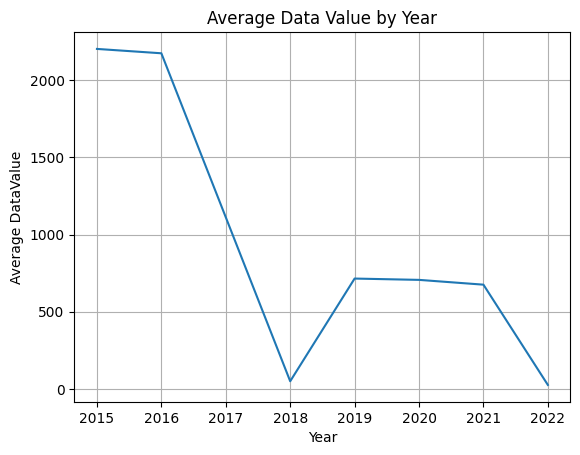

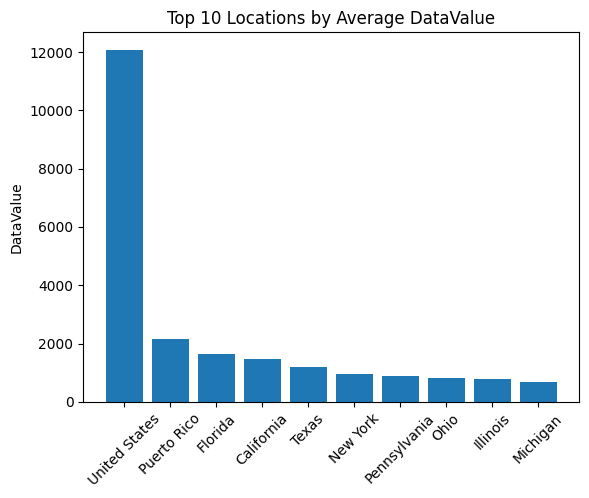

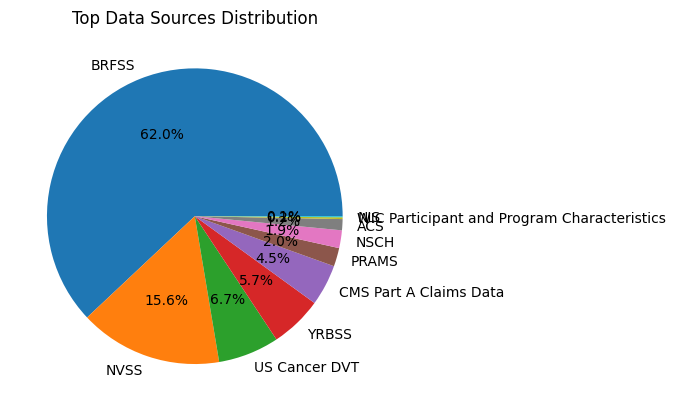

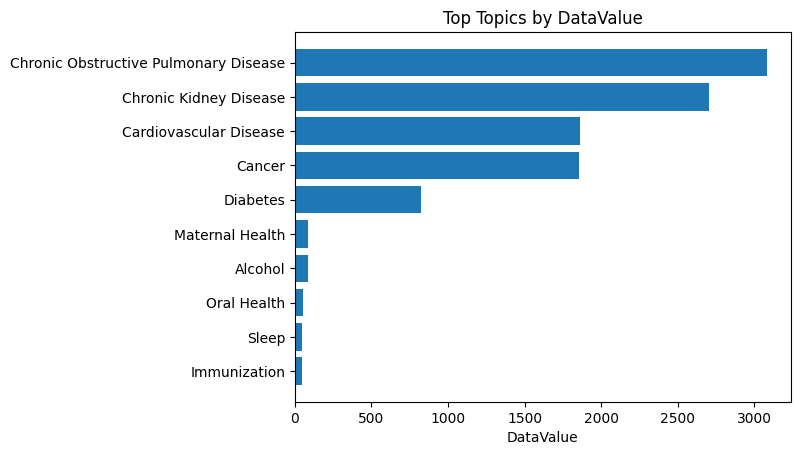

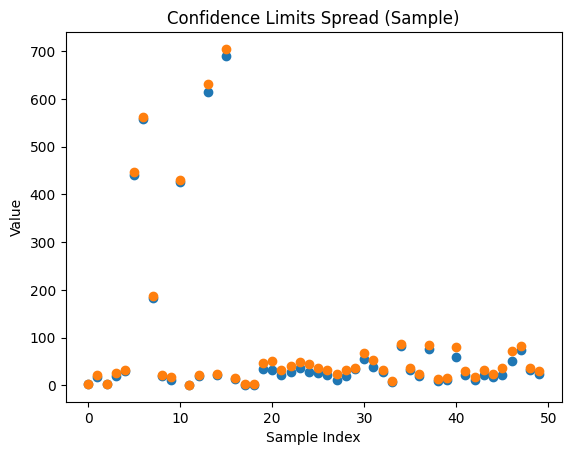

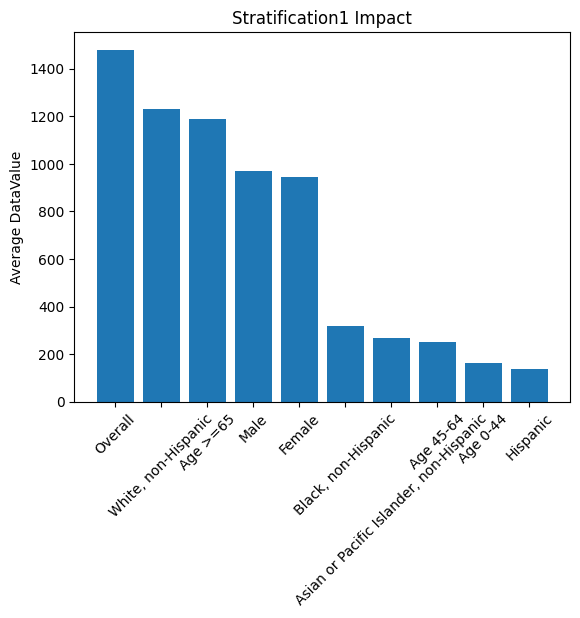

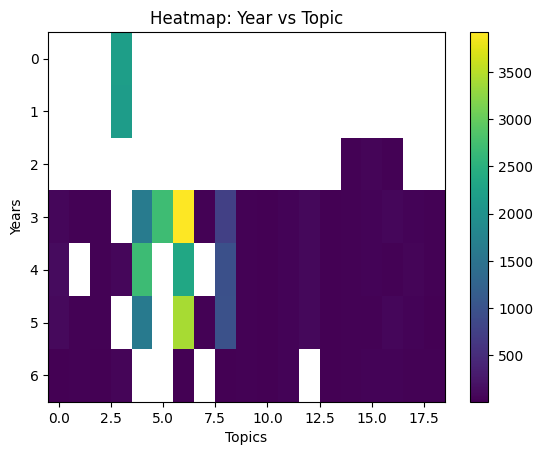

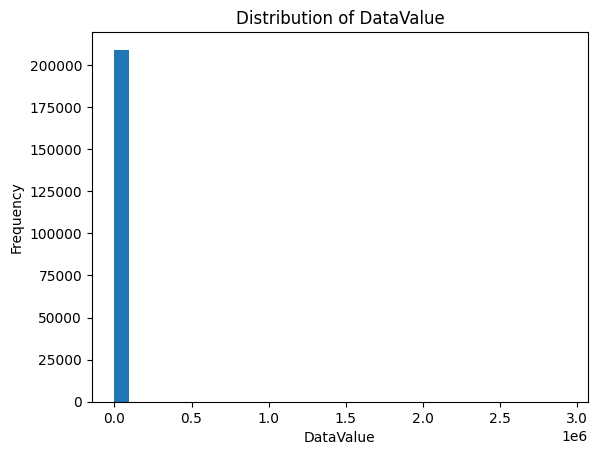

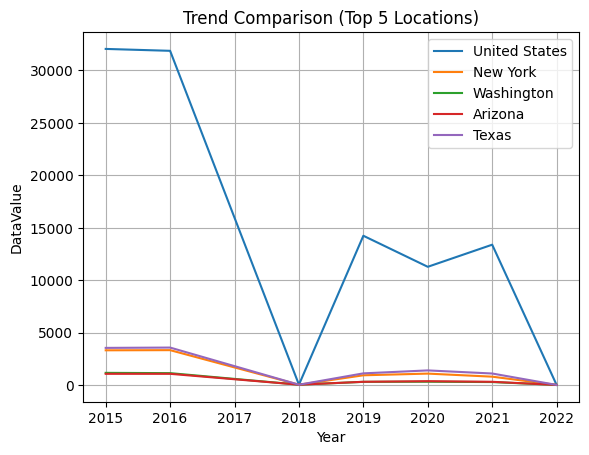

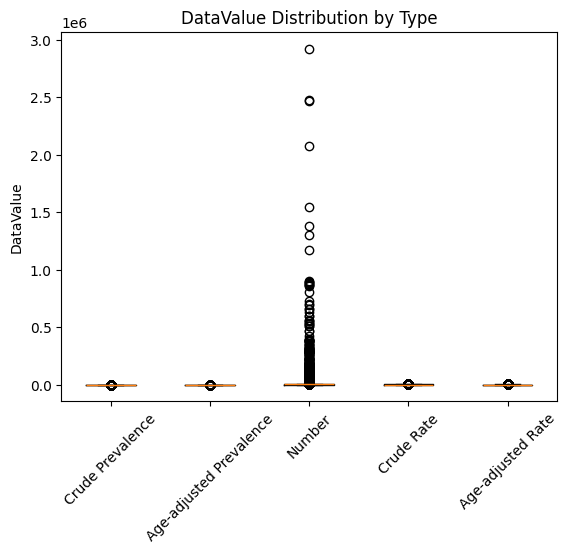

All visualizations completed successfully!


In [12]:
df['DataValue'] = pd.to_numeric(df['DataValue'], errors='coerce')
df['LowConfidenceLimit'] = pd.to_numeric(df['LowConfidenceLimit'], errors='coerce')
df['HighConfidenceLimit'] = pd.to_numeric(df['HighConfidenceLimit'], errors='coerce')

# Drop missing important values
df = df.dropna(subset=['DataValue'])

# ================================
# SET FONT
# ================================
plt.rcParams['font.family'] = 'DejaVu Sans'

# ================================
# 1. YEARLY TREND ANALYSIS
# ================================
yearly = df.groupby('YearStart')['DataValue'].mean()

plt.figure()
plt.plot(yearly.index, yearly.values)
plt.title("Average Data Value by Year")
plt.xlabel("Year")
plt.ylabel("Average DataValue")
plt.grid()
plt.show()

# ================================
# 2. TOP 10 LOCATIONS
# ================================
top_locations = df.groupby('LocationDesc')['DataValue'].mean().sort_values(ascending=False).head(10)

plt.figure()
plt.bar(top_locations.index, top_locations.values)
plt.title("Top 10 Locations by Average DataValue")
plt.xticks(rotation=45)
plt.ylabel("DataValue")
plt.show()

# ================================
# 3. DATA SOURCE DISTRIBUTION
# ================================
source_counts = df['DataSource'].value_counts().head(10)

plt.figure()
plt.pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%')
plt.title("Top Data Sources Distribution")
plt.show()

# ================================
# 4. TOPIC VS VALUE
# ================================
topic_avg = df.groupby('Topic')['DataValue'].mean().sort_values(ascending=False).head(10)

plt.figure()
plt.barh(topic_avg.index, topic_avg.values)
plt.title("Top Topics by DataValue")
plt.xlabel("DataValue")
plt.gca().invert_yaxis()
plt.show()

# ================================
# 5. CONFIDENCE INTERVAL RANGE
# ================================
sample_df = df.dropna(subset=['LowConfidenceLimit', 'HighConfidenceLimit']).head(50)

plt.figure()
plt.scatter(range(len(sample_df)), sample_df['LowConfidenceLimit'])
plt.scatter(range(len(sample_df)), sample_df['HighConfidenceLimit'])
plt.title("Confidence Limits Spread (Sample)")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.show()

# ================================
# 6. STRATIFICATION ANALYSIS
# ================================
strat1 = df.groupby('Stratification1')['DataValue'].mean().sort_values(ascending=False).head(10)

plt.figure()
plt.bar(strat1.index, strat1.values)
plt.title("Stratification1 Impact")
plt.xticks(rotation=45)
plt.ylabel("Average DataValue")
plt.show()

# ================================
# 7. HEATMAP (Pivot Table)
# ================================
pivot = df.pivot_table(values='DataValue', 
                       index='YearStart', 
                       columns='Topic', 
                       aggfunc='mean')

plt.figure()
plt.imshow(pivot, aspect='auto')
plt.title("Heatmap: Year vs Topic")
plt.colorbar()
plt.xlabel("Topics")
plt.ylabel("Years")
plt.show()

# ================================
# 8. DISTRIBUTION OF VALUES
# ================================
plt.figure()
plt.hist(df['DataValue'], bins=30)
plt.title("Distribution of DataValue")
plt.xlabel("DataValue")
plt.ylabel("Frequency")
plt.show()

# ================================
# 9. LOCATION vs YEAR TREND (MULTI-LINE)
# ================================
top5_loc = df['LocationDesc'].value_counts().head(5).index
subset = df[df['LocationDesc'].isin(top5_loc)]

plt.figure()
for loc in top5_loc:
    temp = subset[subset['LocationDesc'] == loc]
    yearly_avg = temp.groupby('YearStart')['DataValue'].mean()
    plt.plot(yearly_avg.index, yearly_avg.values, label=loc)

plt.legend()
plt.title("Trend Comparison (Top 5 Locations)")
plt.xlabel("Year")
plt.ylabel("DataValue")
plt.grid()
plt.show()

# ================================
# 10. BOXPLOT BY DATA TYPE
# ================================
top_types = df['DataValueType'].value_counts().head(5).index
subset_box = df[df['DataValueType'].isin(top_types)]

plt.figure()
data = [subset_box[subset_box['DataValueType'] == t]['DataValue'] for t in top_types]
plt.boxplot(data, labels=top_types)
plt.title("DataValue Distribution by Type")
plt.xticks(rotation=45)
plt.ylabel("DataValue")
plt.show()

# ================================
# DONE
# ================================
print("All visualizations completed successfully!")

## Feature engineering

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc


Logistic Regression Accuracy: 0.9191
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     20919
           1       0.92      0.92      0.92     20921

    accuracy                           0.92     41840
   macro avg       0.92      0.92      0.92     41840
weighted avg       0.92      0.92      0.92     41840


Random Forest Accuracy: 0.9583
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     20919
           1       0.96      0.96      0.96     20921

    accuracy                           0.96     41840
   macro avg       0.96      0.96      0.96     41840
weighted avg       0.96      0.96      0.96     41840


Decision Tree Accuracy: 0.9565
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     20919
           1       0.96      0.96      0.96     20921

    accuracy                           0.96     41840
   macro avg       0.96   

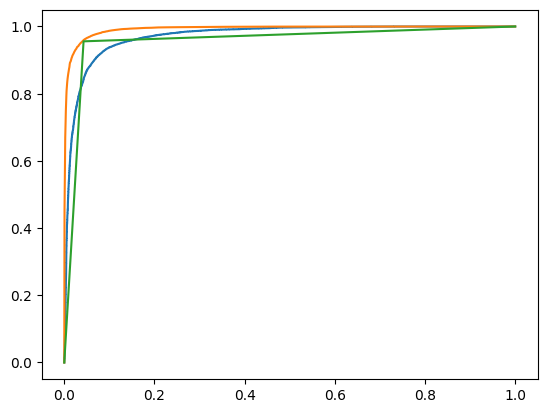

In [14]:
df['DataValue'] = pd.to_numeric(df['DataValue'], errors='coerce')

# TARGET
median_value = df['DataValue'].median()
df['Target'] = np.where(df['DataValue'] >= median_value, 1, 0)

# DROP LEAKAGE COLUMNS
leakage_cols = ['DataValue', 'DataValueAlt', 'LowConfidenceLimit', 'HighConfidenceLimit']
df = df.drop(columns=[col for col in leakage_cols if col in df.columns])

# =========================================
# FEATURES / TARGET
# =========================================
X = df.drop(columns=['Target'])
y = df['Target']

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# COLUMN TYPES
# =========================================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# =========================================
# PREPROCESSING (FIXED ✅)
# =========================================
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # 🔥 FIX
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # 🔥 FIX
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# =========================================
# MODELS
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# =========================================
# TRAIN + EVALUATE
# =========================================
results = {}

plt.figure()

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # TRAIN
    pipeline.fit(X_train, y_train)

    # PREDICT
    y_pred = pipeline.predict(X_test)

    # PROBABILITY
    if hasattr(model, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipeline.decision_function(X_test)

    # ACCURACY
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

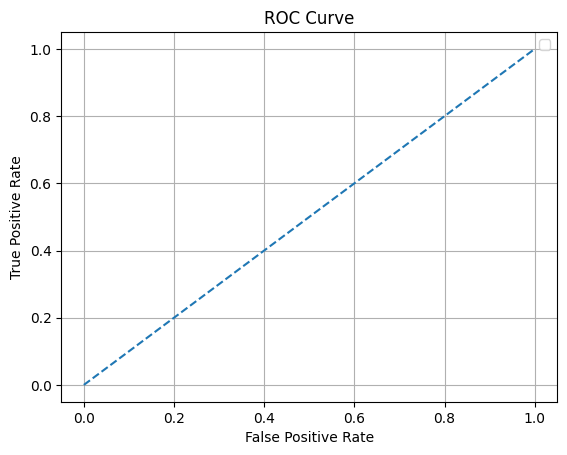

In [15]:
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [16]:
best_model = max(results, key=results.get)
print("\nBest Model:", best_model)
print("Best Accuracy:", results[best_model])


Best Model: Random Forest
Best Accuracy: 0.9582695984703633


## Thank you...pls upvote!!!!!!!!!!!!!!